### Libraries

In [26]:
import os
import numpy as np
import nibabel as nb
import pandas as pd
import glob
import matplotlib.pyplot as plt
import enigmatoolbox
#reload(enigmatoolbox)
#import enigmatoolbox
from enigmatoolbox.plotting import plot_cortical
from enigmatoolbox.utils.parcellation import parcel_to_surface
from enigmatoolbox.utils.parcellation import surface_to_parcel
from enigmatoolbox.datasets import load_sc, load_fc
from nilearn import plotting
from brainspace.mesh.mesh_io import read_surface
from brainspace.plotting import plot_hemispheres
from brainspace.gradient import GradientMaps
from brainspace.mesh.array_operations import smooth_array
from brainstat.datasets import fetch_mask
from brainstat.stats.terms import FixedEffect
from brainstat.stats.SLM import SLM
from scipy.stats import spearmanr
from scipy.stats import pearsonr
from brainspace.datasets import load_mask
from brainspace.utils.parcellation import map_to_labels
import scipy.stats as stats
from scipy import stats
import seaborn as sns
import matplotlib.pyplot as plt
import scipy as sp
from neuromaps.datasets import fetch_fslr
from surfplot import Plot
from brainspace.datasets import load_parcellation
import networkx as nx
from igraph import Graph
import copy
import cmocean
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm
from brainspace.null_models import SpinPermutations

### Load surfaces and masks

In [2]:
# Set dataset PNI as working directory
os.chdir('/data_/mica3/BIDS_PNI/derivatives/micapipe_v0.2.0')

# Path to MICAPIPEsurf = mask_5k !
micapipe=os.popen("echo $MICAPIPE").read()[:-1]

# Load native mid surface
inf_lh = read_surface(micapipe + '/surfaces/fsLR-5k.L.inflated.surf.gii', itype='gii')
inf_rh = read_surface(micapipe + '/surfaces/fsLR-5k.R.inflated.surf.gii', itype='gii')

mask_lh =  nb.load(micapipe + '/surfaces/fsLR-5k.R.mask.shape.gii').darrays[0].data
mask_rh =  nb.load(micapipe + '/surfaces/fsLR-5k.L.mask.shape.gii').darrays[0].data
mask_5k = np.concatenate((mask_lh, mask_rh), axis=0)

# Load fsLR 5k
f5k_lh = read_surface(micapipe + '/surfaces/fsLR-5k.L.surf.gii', itype='gii')
f5k_rh = read_surface(micapipe + '/surfaces/fsLR-5k.R.surf.gii', itype='gii')

# Load fsLR 32k
f32k_lh = read_surface(micapipe + '/surfaces/fsLR-32k.L.surf.gii', itype='gii')
f32k_rh = read_surface(micapipe + '/surfaces/fsLR-32k.R.surf.gii', itype='gii')
# Load fsLR 32k inflated
f32k_inf_lh = read_surface(micapipe + '/surfaces/fsLR-32k.L.inflated.surf.gii', itype='gii')
f32k_inf_rh = read_surface(micapipe + '/surfaces/fsLR-32k.R.inflated.surf.gii', itype='gii')
mask_32k = load_mask(join=True)

# Boolean mask
#mask_surf = mask_5k != 0
mask_surf = mask_32k != 0

## Regional homogeneity (REHO) - neighbor 1

In [9]:
# List of subject IDs
subjIDs = [
    "sub-PNC003", "sub-PNC006", "sub-PNC011", "sub-PNC018", "sub-PNC019",
    "sub-PNC022", "sub-PNC024", "sub-PNC025", "sub-PNC026", "sub-PNC037", "sub-PNC038"
]

# Base path for data
base_path = "/host/verges/tank/data/youngeun/ReHo/neighbors1/fsLR32k_schaefer400"

# List to store ReHo data for all subjects
all_reho = []

# Loop through each subject to read their ReHo data
for subj in subjIDs:
    file_template_lh = f"{base_path}/{subj}_ses-*_surf-fsLR-32k_desc-ReHo.L.shape.gii"  # Template for left hemisphere
    file_template_rh = f"{base_path}/{subj}_ses-*_surf-fsLR-32k_desc-ReHo.R.shape.gii"  # Template for right hemisphere
    
    # Generate file paths for left and right hemispheres
    file_lh = glob.glob(file_template_lh)
    file_rh = glob.glob(file_template_rh)

    file_lh = file_lh[0]
    file_rh = file_rh[0]
    
    # Load ReHo data for left and right hemispheres
    reho_lh = nb.load(file_lh).darrays[0].data
    reho_rh = nb.load(file_rh).darrays[0].data
    
    # Combine left and right hemisphere data
    reho = np.concatenate((reho_lh, reho_rh), axis=0)
    
    # Append combined data to the list
    all_reho.append(reho)

# Stack all subject data into a 2D array (subjects x vertices)
all_reho = np.vstack(all_reho)

# Compute the mean ReHo across subjects (vertex-wise mean)
mean_reho1 = np.mean(all_reho, axis=0)

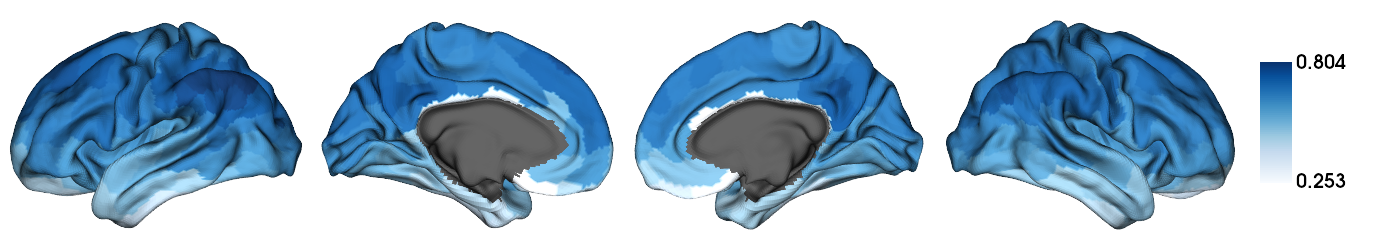

In [11]:
mean_reho1_dc = parcel_to_surface(mean_reho1, 'schaefer_400_conte69')

# Map parcellated data to the surface
mean_reho1_dc[mask_32k == False] = np.nan

plot_hemispheres(f32k_lh, f32k_rh, mean_reho1_dc, cmap='Blues', nan_color=(0.3, 0.3, 0.3, 1),
                      zoom=1.5, size=(1400, 250), embed_nb=True,
                      color_bar='right', cb__labelTextProperty={"fontSize": 20})

## Regional homogeneity (REHO) - neighbor 2

In [13]:
# List of subject IDs
subjIDs = [
    "sub-PNC003", "sub-PNC006", "sub-PNC011", "sub-PNC018", "sub-PNC019",
    "sub-PNC022", "sub-PNC024", "sub-PNC025", "sub-PNC026", "sub-PNC037", "sub-PNC038"
]

# Base path for data
base_path = "/host/verges/tank/data/youngeun/ReHo/neighbors2/fsLR32k_schaefer400"

# List to store ReHo data for all subjects
all_reho = []

# Loop through each subject to read their ReHo data
for subj in subjIDs:
    file_template_lh = f"{base_path}/{subj}_ses-*_surf-fsLR-32k_desc-ReHo.L.shape.gii"  # Template for left hemisphere
    file_template_rh = f"{base_path}/{subj}_ses-*_surf-fsLR-32k_desc-ReHo.R.shape.gii"  # Template for right hemisphere
    
    # Generate file paths for left and right hemispheres
    file_lh = glob.glob(file_template_lh)
    file_rh = glob.glob(file_template_rh)

    file_lh = file_lh[0]
    file_rh = file_rh[0]
    
    # Load ReHo data for left and right hemispheres
    reho_lh = nb.load(file_lh).darrays[0].data
    reho_rh = nb.load(file_rh).darrays[0].data
    
    # Combine left and right hemisphere data
    reho = np.concatenate((reho_lh, reho_rh), axis=0)
    
    # Append combined data to the list
    all_reho.append(reho)

# Stack all subject data into a 2D array (subjects x vertices)
all_reho2 = np.vstack(all_reho)

# Compute the mean ReHo across subjects (vertex-wise mean)
mean_reho2 = np.mean(all_reho, axis=0)

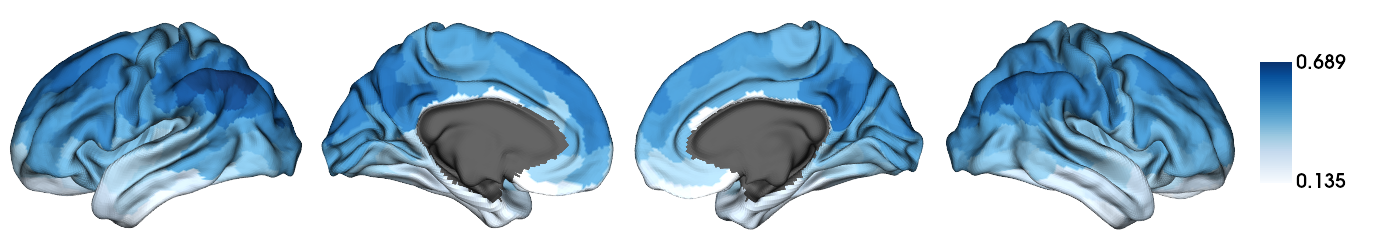

In [14]:
mean_reho2_dc = parcel_to_surface(mean_reho2, 'schaefer_400_conte69')

# Map parcellated data to the surface
mean_reho2_dc[mask_32k == False] = np.nan

plot_hemispheres(f32k_lh, f32k_rh, mean_reho2_dc, cmap='Blues', nan_color=(0.3, 0.3, 0.3, 1),
                      zoom=1.5, size=(1400, 250), embed_nb=True,
                      color_bar='right', cb__labelTextProperty={"fontSize": 20})

## Regional homogeneity (REHO) - neighbor 3

In [15]:
# List of subject IDs
subjIDs = [
    "sub-PNC003", "sub-PNC006", "sub-PNC011", "sub-PNC018", "sub-PNC019",
    "sub-PNC022", "sub-PNC024", "sub-PNC025", "sub-PNC026", "sub-PNC037", "sub-PNC038"
]

# Base path for data
base_path = "/host/verges/tank/data/youngeun/ReHo/neighbors3/fsLR32k_schaefer400"

# List to store ReHo data for all subjects
all_reho = []

# Loop through each subject to read their ReHo data
for subj in subjIDs:
    file_template_lh = f"{base_path}/{subj}_ses-*_surf-fsLR-32k_desc-ReHo.L.shape.gii"  # Template for left hemisphere
    file_template_rh = f"{base_path}/{subj}_ses-*_surf-fsLR-32k_desc-ReHo.R.shape.gii"  # Template for right hemisphere
    
    # Generate file paths for left and right hemispheres
    file_lh = glob.glob(file_template_lh)
    file_rh = glob.glob(file_template_rh)

    file_lh = file_lh[0]
    file_rh = file_rh[0]
    
    # Load ReHo data for left and right hemispheres
    reho_lh = nb.load(file_lh).darrays[0].data
    reho_rh = nb.load(file_rh).darrays[0].data
    
    # Combine left and right hemisphere data
    reho = np.concatenate((reho_lh, reho_rh), axis=0)
    
    # Append combined data to the list
    all_reho.append(reho)

# Stack all subject data into a 2D array (subjects x vertices)
all_reho3 = np.vstack(all_reho)

# Compute the mean ReHo across subjects (vertex-wise mean)
mean_reho3 = np.mean(all_reho, axis=0)

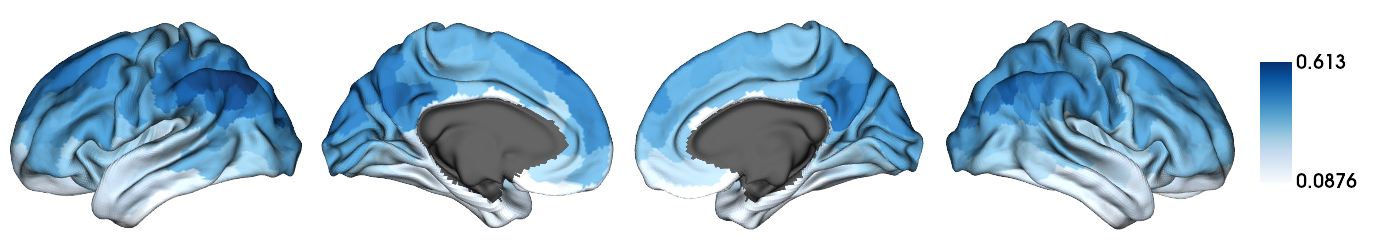

In [16]:
mean_reho3_dc = parcel_to_surface(mean_reho3, 'schaefer_400_conte69')

# Map parcellated data to the surface
mean_reho3_dc[mask_32k == False] = np.nan

plot_hemispheres(f32k_lh, f32k_rh, mean_reho3_dc, cmap='Blues', nan_color=(0.3, 0.3, 0.3, 1),
                      zoom=1.5, size=(1400, 250), embed_nb=True,
                      color_bar='right', cb__labelTextProperty={"fontSize": 20})

### Functions

## F1: Intensity Smoothing

In [17]:
# Function: Smooth intensity profiles on a given surface
def smooth_surf(surf_l, surf_r, points, Mask, Kernel='uniform', Niter=3, Relax=0.35):
    '''
    Smooths intensity data on a given surface mesh using iterative smoothing.
    
    Parameters:
    -----------
    surf_l : np.array
        Left hemisphere surface connectivity.
    surf_r : np.array
        Right hemisphere surface connectivity.
    points : np.array
        Intensity profile data mapped to the surface.
    Mask : np.array
        Binary mask indicating valid regions for smoothing.
    Kernel : str, optional
        Smoothing kernel type, options: {'uniform', 'gaussian', 'inverse_distance'}.
    Niter : int, optional
        Number of smoothing iterations (default: 3).
    Relax : float, optional
        Relaxation factor controlling smoothing intensity (default: 0.35).
    
    Returns:
    --------
    sdata : np.array
        Smoothed intensity data.
    '''
    Ndim = Mask.shape[0] 
    n2dim = int(Ndim/2)
    Mask_l = Mask[:n2dim]
    Mask_r = Mask[n2dim:]
    
    sdata = np.concatenate((
        smooth_array(surf_l, points[:n2dim], kernel=Kernel, n_iter=Niter, relax=Relax, mask=Mask_l), 
        smooth_array(surf_r, points[n2dim:], kernel=Kernel, n_iter=Niter, relax=Relax, mask=Mask_r)
    ), axis=0)
    
    return sdata

# Function: Apply smoothing to intensity profiles across all depths
def smooth_intensities(int_profile):
    '''
    Applies surface smoothing to each depth of the intensity profile.
    
    Parameters:
    -----------
    int_profile : np.array
        Input intensity profiles, where rows represent different depths.
    
    Returns:
    --------
    smoothed_i : np.array
        Smoothed intensity profiles.
    '''
    smoothed_i = np.copy(int_profile)
    
    for i in range(int_profile.shape[0]):
        smoothed_i[i, :] = smooth_surf(
            f32k_inf_lh, f32k_inf_rh, int_profile[i, :], mask_surf, Niter=5, Relax=0.5, Kernel='uniform'
        )
    
    return smoothed_i

In [18]:
def fill_missing_Turkey(cdata):
    # Calculate the first and third quartiles
    Q1 = np.nanpercentile(cdata, 25)
    Q3 = np.nanpercentile(cdata, 75)

    # Calculate the interquartile range (IQR)
    IQR = Q3 - Q1

    # Define the outlier thresholds based on Tukey's method
    lower_threshold = Q1 - 1.5 * IQR
    upper_threshold = Q3 + 1.5 * IQR

    # Identify outliers based on Tukey's method
    outliers = (cdata < lower_threshold) | (cdata > upper_threshold)

    # Set outliers to NaN
    cdata[outliers] = np.nan

    # Interpolate NaNs
    good = np.where(~np.isnan(cdata))
    bad = np.where(np.isnan(cdata))
    fill = sp.interpolate.griddata(good, cdata[good], bad)
    cdata[bad] = fill

    # Extrapolate any remaining missing values
    good = np.where(~np.isnan(cdata))
    bad = np.where(np.isnan(cdata))
    fill = sp.interpolate.griddata(good, cdata[good], bad, method='nearest')
    cdata[bad] = fill
    
    return cdata

## F3: Spin permutations: Brain functional connectivity ~ SWM long-range fibers by subject

In [21]:
# Shape of the fsLR-32k matrices
N5k = 64984

# Load spheres fsLR32k
sphere_lh = read_surface(micapipe+'/surfaces/fsLR-32k.L.sphere.surf.gii', itype='gii')
sphere_rh = read_surface(micapipe+'/surfaces/fsLR-32k.R.sphere.surf.gii', itype='gii')

# Let's create some rotations
n_rand = 1000

spinp = SpinPermutations(n_rep=n_rand, random_state=0)
spinp.fit(sphere_lh, points_rh=sphere_rh)

SpinPermutations(n_rep=1000, random_state=0)

In [63]:
def plot_reho_spin_permutations(sub7T_id, sub3T_di):
    
    # Load functional connectivity data (left & right hemispheres)
    rfile_path_lh = glob.glob(f"/host/verges/tank/data/youngeun/ReHo/neighbors1/fsLR32k/sub-PNC0{sub7T_id}_ses-*_surf-fsLR-32k_desc-ReHo.L.shape.gii")[0]
    rfile_path_rh = glob.glob(f"/host/verges/tank/data/youngeun/ReHo/neighbors1/fsLR32k/sub-PNC0{sub7T_id}_ses-*_surf-fsLR-32k_desc-ReHo.R.shape.gii")[0]
    
    # Load ReHo data for left and right hemispheres
    reho_lh = nb.load(rfile_path_lh).darrays[0].data
    reho_rh = nb.load(rfile_path_rh).darrays[0].data
    
    # Combine left and right hemisphere data
    reho = np.concatenate((reho_lh, reho_rh), axis=0)
    reho = reho.reshape(-1)

    #reho_dc = parcel_to_surface(reho, 'schaefer_400_conte69')
   
    rdata_L = reho[0:int(N5k/2)]
    rdata_R = reho[int(N5k/2):N5k]

    ###################################################################################################
    # Load apparent fiber density maps - Long-range fibers
    base_dir = '/host/verges/tank/data/youngeun/myproject/FBA/subjects'
    subj_path = os.path.join(base_dir, sub3T_di, 'csd_msmt')
    lh_LFpath = os.path.join(subj_path, 'L_fsLR32k_afd-par.txt')
    rh_LFpath = os.path.join(subj_path, 'R_fsLR32k_afd-par.txt')
    
    lh_LFpar = np.loadtxt(lh_LFpath)
    rh_LFpar = np.loadtxt(rh_LFpath)

    # column 0 (0mm), 2 (1mm), 4 (2mm)
    LFpar_0mm = np.concatenate((lh_LFpar[:, 0], rh_LFpar[:, 0]), axis=0)
    LFpar_1mm = np.concatenate((lh_LFpar[:, 2], rh_LFpar[:, 2]), axis=0)
    LFpar_2mm = np.concatenate((lh_LFpar[:, 4], rh_LFpar[:, 4]), axis=0)

    # Convert -1 to NaN for missing values
    LFpar_0mm[LFpar_0mm == -1] = np.nan
    LFpar_1mm[LFpar_1mm == -1] = np.nan
    LFpar_2mm[LFpar_2mm == -1] = np.nan
    
    LFpar_SWM = np.vstack([LFpar_0mm, LFpar_1mm, LFpar_2mm])  # shape: (3, vertices)

    # Fill missing data using Turkey's method
    LF_filled_matrix = np.empty_like(LFpar_SWM)
    for i, row in enumerate(LFpar_SWM):
        LF_filled_matrix[i] = fill_missing_Turkey(row)

    LF_par_smooth = smooth_intensities(LF_filled_matrix)
    LF_2mm = LF_par_smooth[2, :]
    #LF_2mm_parc = surface_to_parcel(LF_2mm, 'schaefer_400_conte69')
    #LF_2mm_dc = parcel_to_surface(LF_2mm_parc, 'schaefer_400_conte69')
    
    ###################################################################################################
    # Load apparent fiber density maps - U-fibers
    lh_UFpath = os.path.join(subj_path, 'L_fsLR32k_afd-perp-av.txt')
    rh_UFpath = os.path.join(subj_path, 'R_fsLR32k_afd-perp-av.txt')
    
    lh_UFpar = np.loadtxt(lh_UFpath)
    rh_UFpar = np.loadtxt(rh_UFpath)

    # column 0 (0mm), 2 (1mm), 4 (2mm)
    UFpar_0mm = np.concatenate((lh_UFpar[:, 0], rh_UFpar[:, 0]), axis=0)
    UFpar_1mm = np.concatenate((lh_UFpar[:, 2], rh_UFpar[:, 2]), axis=0)
    UFpar_2mm = np.concatenate((lh_UFpar[:, 4], rh_UFpar[:, 4]), axis=0)

    # Convert -1 to NaN for missing values
    UFpar_0mm[UFpar_0mm == -1] = np.nan
    UFpar_1mm[UFpar_1mm == -1] = np.nan
    UFpar_2mm[UFpar_2mm == -1] = np.nan
    
    UFpar_SWM = np.vstack([UFpar_0mm, UFpar_1mm, UFpar_2mm])  # shape: (3, vertices)

    # Fill missing data using Turkey's method
    UF_filled_matrix = np.empty_like(UFpar_SWM)
    for i, row in enumerate(UFpar_SWM):
        UF_filled_matrix[i] = fill_missing_Turkey(row)

    UF_par_smooth = smooth_intensities(UF_filled_matrix)
    UF_2mm = UF_par_smooth[2, :]
    #UF_2mm_parc = surface_to_parcel(UF_2mm, 'schaefer_400_conte69')
    #UF_2mm_dc = parcel_to_surface(UF_2mm_parc, 'schaefer_400_conte69')

    ###################################################################################################
    # Spin permutation on full data (Get the rotated data)
    func_rotated = np.hstack(spinp.randomize(rdata_L, rdata_R))
    
    AFDs = {'long-range fibers': LF_2mm, 'u-fibers': UF_2mm}
    
    # Plotting
    fig, axs = plt.subplots(1, 2, figsize=(8, 4))
    
    for k, (fn, AFD) in enumerate(AFDs.items()):

        mask = ~np.isnan(reho) & ~np.isnan(AFD)
        non_zero_mask = ~((reho[mask] == 0) & (AFD[mask] == 0))
        valid_rc = reho[mask][non_zero_mask]
        valid_afd = AFD[mask][non_zero_mask]
        
        # Observed correlation
        r_obs, p_obs = spearmanr(valid_rc, valid_afd)
        
        # Permutation-based correlations
        r_spin = np.array([spearmanr(perm[mask][non_zero_mask], valid_afd)[0] for perm in func_rotated])
        p_spin = np.mean(np.abs(r_spin) >= np.abs(r_obs))
        
        # Plot null distribution
        axs[k].hist(r_spin, bins=25, density=True, alpha=0.5, color=(.6, .6, .6))
        axs[k].axvline(r_obs, lw=2, ls='--', color='k')
        axs[k].set_xlabel(f'Correlation with {fn}')
        if k == 0:
            axs[k].set_ylabel('Density')
        #textstr = f'Obs: r = {r_obs:.3f}, p = {p_obs:.3f}\nSpin: r = {np.mean(r_spin):.3f}, p = {p_spin:.3f}'
        textstr = f"r = {r_obs:.3f}, $P_{{spin}}$ = {p_spin:.3f}"
        axs[k].text(0.95, 0.95, textstr, transform=axs[k].transAxes, fontsize=12,
                    verticalalignment='top', horizontalalignment='right',
                    bbox=dict(boxstyle='round,pad=0.3', edgecolor='gray', facecolor='white'))
    
    fig.tight_layout()
    plt.show()

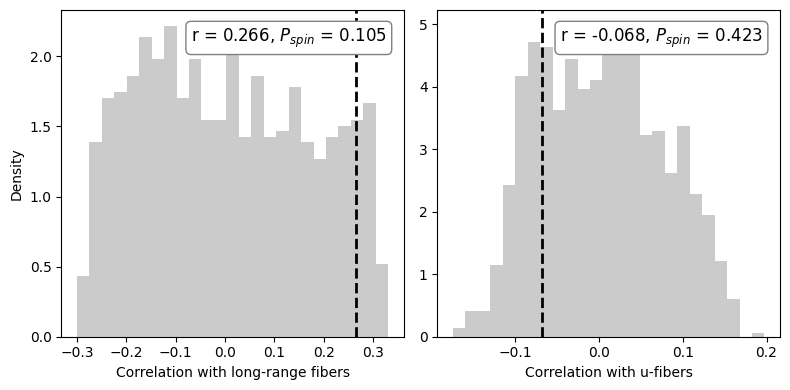

In [64]:
plot_reho_spin_permutations(sub7T_id="03", sub3T_di="PNC003_HC082")

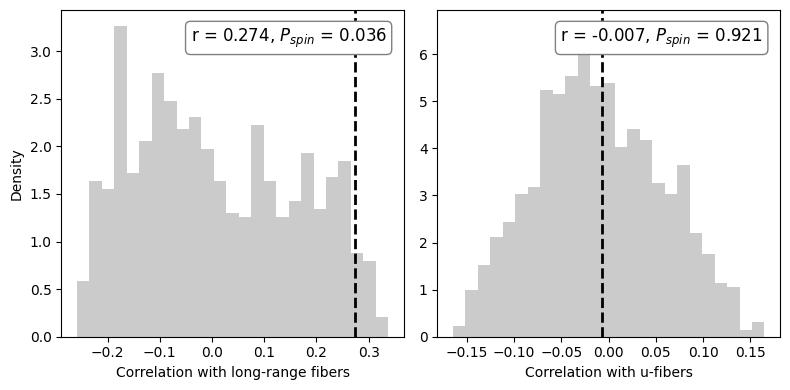

In [65]:
plot_reho_spin_permutations(sub7T_id="06", sub3T_di="PNC006_HC081")

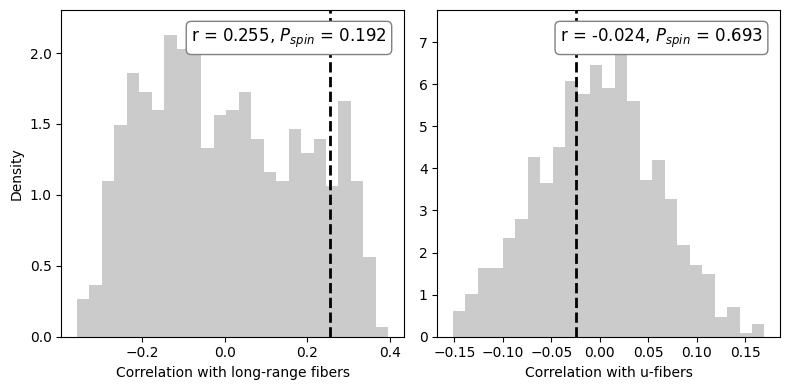

In [66]:
plot_reho_spin_permutations(sub7T_id="11", sub3T_di="PNC011_HC083")

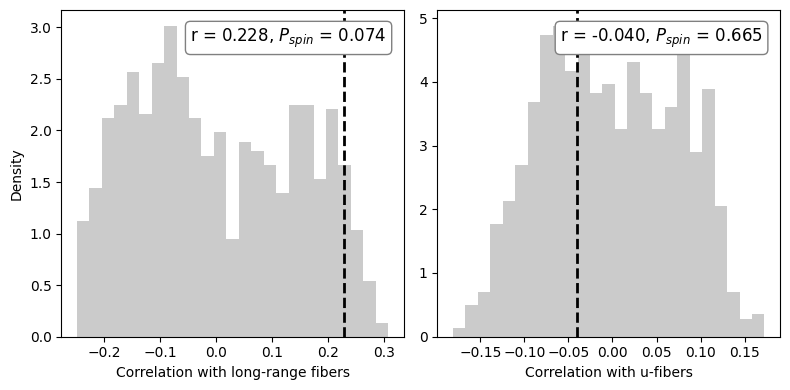

In [67]:
plot_reho_spin_permutations(sub7T_id="18", sub3T_di="PNC018_HC076")

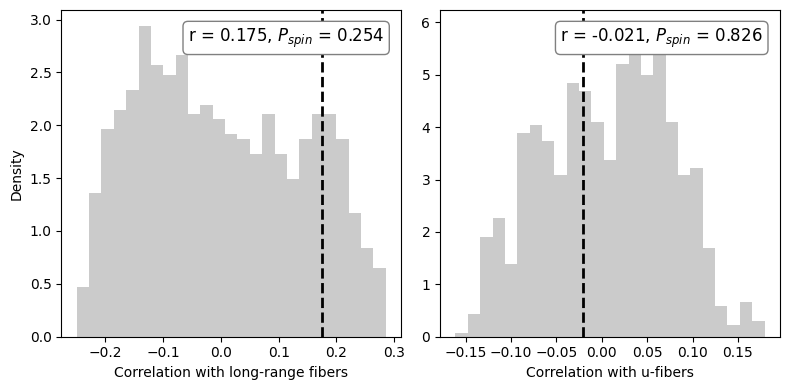

In [68]:
plot_reho_spin_permutations(sub7T_id="19", sub3T_di="PNC019_HC062")

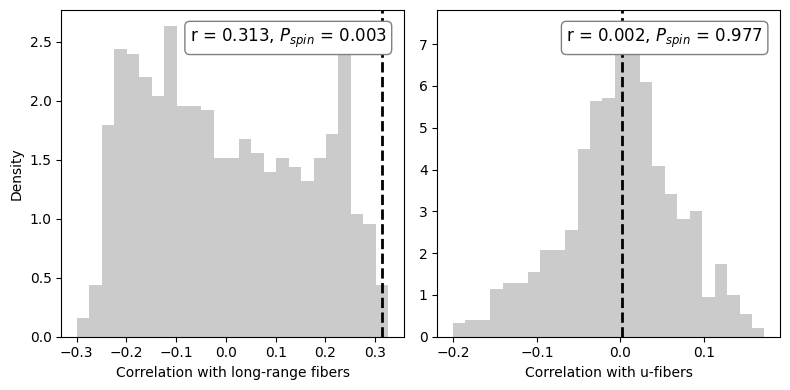

In [69]:
plot_reho_spin_permutations(sub7T_id="22", sub3T_di="PNC022_HC132")

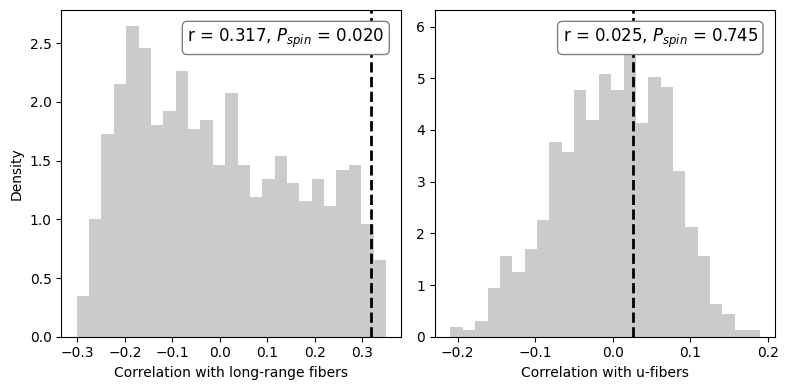

In [70]:
plot_reho_spin_permutations(sub7T_id="24", sub3T_di="PNC024_HC088")

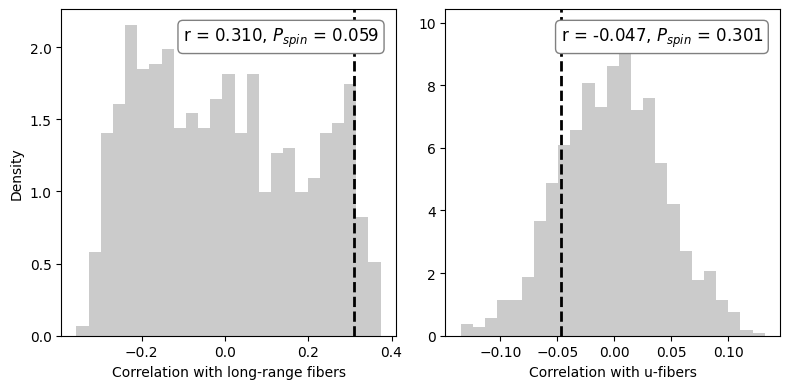

In [71]:
plot_reho_spin_permutations(sub7T_id="25", sub3T_di="PNC025_HC128")

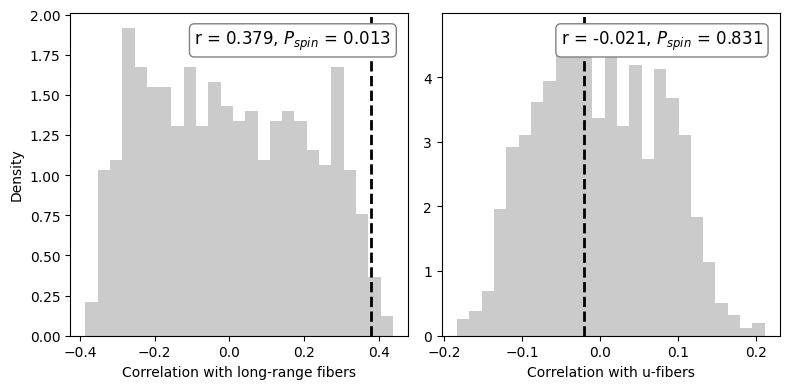

In [72]:
plot_reho_spin_permutations(sub7T_id="26", sub3T_di="PNC026_HC130")

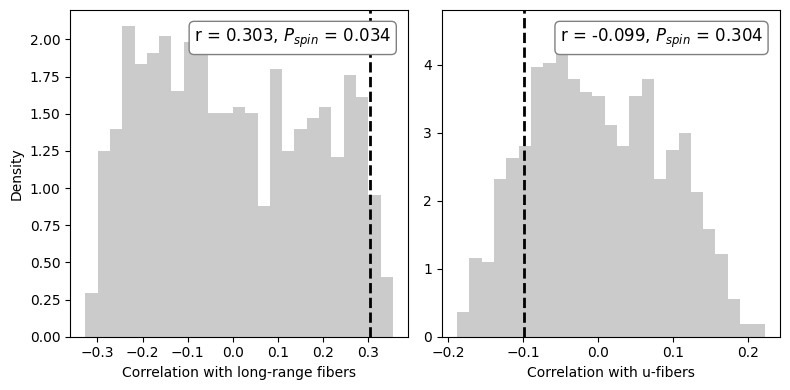

In [73]:
plot_reho_spin_permutations(sub7T_id="37", sub3T_di="PNC037_HC116")

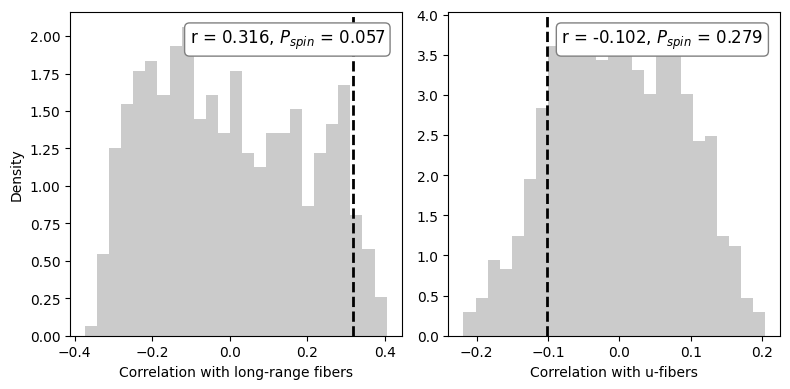

In [74]:
plot_reho_spin_permutations(sub7T_id="38", sub3T_di="PNC038_HC140")